# CNN1D_v3 — Adaptive Robust 1D-SCNN

Notebook ini mengimplementasikan model utama untuk mengejar performa terbaik pada skenario SeNic yang paling sulit: **electrode shift** dan **inter-day**. Fokusnya adalah 1D-CNN robust dengan envelope branch, depthwise separable convolution, ECA channel attention, augmentation rotasi channel, dan supervised calibration/fine-tuning.


In [1]:
from pathlib import Path
import sys

try:
    import config
except ImportError:
    cwd = Path.cwd()
    candidates = [cwd, cwd.parent, cwd.parent.parent]
    for p in candidates:
        if (p / "config.py").exists():
            sys.path.insert(0, str(p))
            break
    import config

PROJECT_ROOT = config.PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import copy
import json
import math
import random
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

from config import (
    METADATA_PATH, WINDOWS_DIR, RESULTS_DIR, MODELS_DIR, FIGURES_DIR,
    N_CHANNELS, N_CLASSES, GESTURE_CLASSES, RANDOM_SEED,
    SUBJECTS_NON_FATIGUE, SUBJECTS_FATIGUE, SUBJECTS_INTERDAY_LONG,
    get_device,
)

DEVICE = get_device()
print("Device:", DEVICE)


Device: mps


In [2]:
SEED = RANDOM_SEED
USE_ENVELOPE = True
BATCH_SIZE = 256
NUM_WORKERS = 0
CACHE_SIZE = 24

BASE_EPOCHS = 45
ADAPT_EPOCHS = 18
FATIGUE_EPOCHS = 35
PATIENCE = 8

LR_BASE = 8e-4
LR_ADAPT = 2e-4
WEIGHT_DECAY = 1e-3
LABEL_SMOOTHING = 0.03

SHIFT_CAL_POSITIONS = list(range(1, 11))
SHIFT_CAL_REPS = [0, 1]
SHIFT_TEST_REPS = [2]

INTERDAY_CAL_REPS = [0, 1]
INTERDAY_TEST_REPS = [2]

BEST_METRIC = "accuracy"


In [3]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "logs").mkdir(parents=True, exist_ok=True)


## Load metadata

In [4]:
def load_metadata():
    meta = pd.read_csv(METADATA_PATH)
    if "is_valid" in meta.columns:
        meta = meta[meta["is_valid"]].copy()
    meta = meta.reset_index(drop=True)
    meta["window_file_path"] = meta["window_file_path"].astype(str)
    return meta

meta = load_metadata()
print(meta.shape)
print(meta[["subject", "session", "position", "repetition", "gesture", "gesture_label", "n_windows"]].head())
print("Subjects:", meta["subject"].nunique(), "Trials:", len(meta), "Windows:", int(meta["n_windows"].sum()))


(24457, 15)
  subject  session  position  repetition             gesture  gesture_label  \
0      h0        0         0           0            eversion              5   
1      h0        0         0           0                fist              0   
2      h0        0         0           0           open_hand              1   
3      h0        0         0           0    pinch_forefinger              2   
4      h0        0         0           0  pinch_middlefinger              3   

   n_windows  
0        118  
1        116  
2        111  
3        104  
4         98  
Subjects: 36 Trials: 24457 Windows: 2792999


In [5]:
def existing_window_path(path_str):
    p = Path(path_str)
    if p.exists():
        return p
    alt = PROJECT_ROOT / p
    if alt.exists():
        return alt
    alt = WINDOWS_DIR / p.name
    if alt.exists():
        return alt
    return p

missing = []
for p in meta["window_file_path"].head(20):
    if not existing_window_path(p).exists():
        missing.append(p)
print("Sample missing window files:", len(missing))
if missing:
    print(missing[:3])


Sample missing window files: 0


## Dataset, normalization, and augmentation

In [6]:
def compute_channel_stats(df):
    total = np.zeros((N_CHANNELS,), dtype=np.float64)
    total_sq = np.zeros((N_CHANNELS,), dtype=np.float64)
    count = 0

    for path in tqdm(df["window_file_path"].tolist(), desc="Computing normalization"):
        p = existing_window_path(path)
        data = np.load(p)
        w = data["windows"].astype(np.float32)
        if w.shape[0] == 0:
            continue
        total += w.sum(axis=(0, 2))
        total_sq += (w ** 2).sum(axis=(0, 2))
        count += w.shape[0] * w.shape[2]

    mean = total / max(count, 1)
    var = total_sq / max(count, 1) - mean ** 2
    std = np.sqrt(np.maximum(var, 1e-8))
    return mean.reshape(1, N_CHANNELS, 1).astype(np.float32), std.reshape(1, N_CHANNELS, 1).astype(np.float32)


def normalize_windows(w, mean, std):
    return np.nan_to_num((w - mean) / std, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


In [7]:
class TrialWindowDataset(Dataset):
    def __init__(self, df, mean, std, augment=False, use_envelope=USE_ENVELOPE, cache_size=CACHE_SIZE):
        self.df = df.reset_index(drop=True).copy()
        self.mean = mean
        self.std = std
        self.augment = augment
        self.use_envelope = use_envelope
        self.cache_size = cache_size
        self.lengths = self.df["n_windows"].astype(int).clip(lower=0).to_numpy()
        self.cum = np.cumsum(self.lengths)
        self.cache = OrderedDict()

    def __len__(self):
        return int(self.cum[-1]) if len(self.cum) else 0

    def _load_trial(self, row_idx):
        if row_idx in self.cache:
            self.cache.move_to_end(row_idx)
            return self.cache[row_idx]

        row = self.df.iloc[row_idx]
        p = existing_window_path(row["window_file_path"])
        data = np.load(p)
        raw = data["windows"].astype(np.float32)
        raw = normalize_windows(raw, self.mean, self.std)

        if self.use_envelope:
            env = np.abs(hilbert(raw, axis=2)).astype(np.float32)
            x = np.concatenate([raw, env], axis=1)
        else:
            x = raw

        y = int(row["gesture_label"])
        self.cache[row_idx] = (x, y)
        if len(self.cache) > self.cache_size:
            self.cache.popitem(last=False)
        return x, y

    def _augment(self, x):
        x = x.copy()
        c = 8

        if np.random.rand() < 0.80:
            s = np.random.randint(-3, 4)
            if s != 0:
                x[:c] = np.roll(x[:c], s, axis=0)
                if x.shape[0] >= 2 * c:
                    x[c:2*c] = np.roll(x[c:2*c], s, axis=0)

        if np.random.rand() < 0.75:
            scale = np.random.normal(1.0, 0.12, size=(c, 1)).astype(np.float32)
            x[:c] *= scale
            if x.shape[0] >= 2 * c:
                x[c:2*c] *= np.abs(scale)

        if np.random.rand() < 0.50:
            x += np.random.normal(0.0, 0.025, size=x.shape).astype(np.float32)

        if np.random.rand() < 0.35:
            t = np.random.randint(-4, 5)
            x = np.roll(x, t, axis=1)

        if np.random.rand() < 0.25:
            drop = np.random.rand(c) < 0.10
            x[:c][drop] = 0.0
            if x.shape[0] >= 2 * c:
                x[c:2*c][drop] = 0.0

        return x

    def __getitem__(self, idx):
        row_idx = int(np.searchsorted(self.cum, idx, side="right"))
        start = 0 if row_idx == 0 else int(self.cum[row_idx - 1])
        local_idx = int(idx - start)
        x_all, y = self._load_trial(row_idx)
        x = x_all[local_idx]
        if self.augment:
            x = self._augment(x)
        return torch.from_numpy(x.astype(np.float32)), torch.tensor(y, dtype=torch.long)


In [8]:
def split_train_val_by_trial(df, val_frac=0.15, seed=SEED):
    rng = np.random.RandomState(seed)
    val_idx = []
    for _, g in df.groupby("gesture_label"):
        idx = g.index.to_numpy()
        n_val = max(1, int(round(len(idx) * val_frac))) if len(idx) > 4 else 1
        val_idx.extend(rng.choice(idx, size=n_val, replace=False).tolist())
    val_idx = sorted(set(val_idx))
    val_df = df.loc[val_idx].copy()
    train_df = df.drop(index=val_idx).copy()
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True)


def make_loader(df, mean, std, batch_size=BATCH_SIZE, shuffle=False, augment=False):
    ds = TrialWindowDataset(df, mean, std, augment=augment)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=False)


## Adaptive Robust 1D-SCNN model

In [9]:
class ECA1D(nn.Module):
    def __init__(self, channels, k_size=3):
        super().__init__()
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)

    def forward(self, x):
        y = x.mean(dim=2, keepdim=False).unsqueeze(1)
        y = torch.sigmoid(self.conv(y)).squeeze(1).unsqueeze(2)
        return x * y


class DSConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=5, dilation=1, dropout=0.15):
        super().__init__()
        pad = ((kernel_size - 1) // 2) * dilation
        self.depth = nn.Conv1d(in_ch, in_ch, kernel_size, padding=pad, dilation=dilation, groups=in_ch, bias=False)
        self.point = nn.Conv1d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm1d(out_ch)
        self.eca = ECA1D(out_ch)
        self.drop = nn.Dropout(dropout)
        self.res = nn.Conv1d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        y = self.depth(x)
        y = self.point(y)
        y = self.bn(y)
        y = F.gelu(y)
        y = self.eca(y)
        y = self.drop(y)
        return F.gelu(y + self.res(x))


class AdaptiveRobustCNN1D(nn.Module):
    def __init__(self, in_channels=16, n_classes=N_CLASSES, width=80, dropout=0.25):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, width, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(width),
            nn.GELU(),
        )
        self.blocks = nn.ModuleList([
            DSConvBlock(width, width, kernel_size=5, dilation=1, dropout=0.12),
            DSConvBlock(width, width, kernel_size=5, dilation=2, dropout=0.12),
            DSConvBlock(width, width * 2, kernel_size=5, dilation=1, dropout=0.16),
            DSConvBlock(width * 2, width * 2, kernel_size=3, dilation=2, dropout=0.16),
        ])
        self.final_norm = nn.BatchNorm1d(width * 2)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(width * 2, width),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(width, n_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        for block in self.blocks:
            x = block(x)
        x = self.final_norm(x)
        x = self.pool(x)
        return self.classifier(x)


def build_model():
    in_ch = 16 if USE_ENVELOPE else 8
    return AdaptiveRobustCNN1D(in_channels=in_ch).to(DEVICE)


## Training and evaluation utilities

In [10]:
def evaluate(model, loader):
    model.eval()
    preds, trues = [], []
    loss_sum, n = 0.0, 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            logits = model(x)
            loss = criterion(logits, y)
            pred = logits.argmax(dim=1)
            preds.append(pred.cpu().numpy())
            trues.append(y.cpu().numpy())
            loss_sum += float(loss.item()) * y.size(0)
            n += y.size(0)

    y_true = np.concatenate(trues) if trues else np.array([])
    y_pred = np.concatenate(preds) if preds else np.array([])
    return {
        "loss": loss_sum / max(n, 1),
        "accuracy": accuracy_score(y_true, y_pred) if len(y_true) else 0.0,
        "f1_macro": f1_score(y_true, y_pred, average="macro") if len(y_true) else 0.0,
        "y_true": y_true,
        "y_pred": y_pred,
    }


def train_model(model, train_loader, val_loader, epochs, lr, weight_decay=WEIGHT_DECAY, patience=PATIENCE, title="model"):
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    best_state = copy.deepcopy(model.state_dict())
    best_score = -1.0
    bad = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss, n = 0.0, 0
        pbar = tqdm(train_loader, desc=f"{title} epoch {epoch}/{epochs}", leave=False)
        for x, y in pbar:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 3.0)
            optimizer.step()
            train_loss += float(loss.item()) * y.size(0)
            n += y.size(0)
            pbar.set_postfix(loss=train_loss / max(n, 1))

        val = evaluate(model, val_loader)
        row = {"epoch": epoch, "train_loss": train_loss / max(n, 1), "val_loss": val["loss"], "val_accuracy": val["accuracy"], "val_f1_macro": val["f1_macro"]}
        history.append(row)
        print(f"{title} | epoch {epoch:02d} | train_loss={row['train_loss']:.4f} | val_acc={row['val_accuracy']:.4f} | val_f1={row['val_f1_macro']:.4f}")

        score = row[f"val_{BEST_METRIC}"]
        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


In [11]:
def set_finetune_mode(model, mode="head_last"):
    for p in model.parameters():
        p.requires_grad = False

    if mode == "head":
        modules = [model.classifier]
    elif mode == "head_last":
        modules = [model.blocks[-1], model.final_norm, model.classifier]
    elif mode == "all":
        modules = [model]
    else:
        raise ValueError(mode)

    for module in modules:
        for p in module.parameters():
            p.requires_grad = True

    return model


def fit_from_df(train_df, val_df=None, epochs=BASE_EPOCHS, lr=LR_BASE, augment=True, title="train"):
    if val_df is None:
        train_df, val_df = split_train_val_by_trial(train_df)
    mean, std = compute_channel_stats(train_df)
    train_loader = make_loader(train_df, mean, std, shuffle=True, augment=augment)
    val_loader = make_loader(val_df, mean, std, shuffle=False, augment=False)
    model = build_model()
    model, hist = train_model(model, train_loader, val_loader, epochs=epochs, lr=lr, title=title)
    return model, mean, std, hist


def adapt_model(base_model, cal_df, base_mean, base_std, epochs=ADAPT_EPOCHS, lr=LR_ADAPT, mode="head_last", title="adapt"):
    cal_train, cal_val = split_train_val_by_trial(cal_df, val_frac=0.20)
    model = copy.deepcopy(base_model).to(DEVICE)
    set_finetune_mode(model, mode=mode)
    train_loader = make_loader(cal_train, base_mean, base_std, shuffle=True, augment=True)
    val_loader = make_loader(cal_val, base_mean, base_std, shuffle=False, augment=False)
    model, hist = train_model(model, train_loader, val_loader, epochs=epochs, lr=lr, patience=max(5, PATIENCE // 2), title=title)
    for p in model.parameters():
        p.requires_grad = True
    return model, hist


In [12]:
def evaluate_by_group(model, df, mean, std, group_col, batch_size=BATCH_SIZE):
    rows = []
    for group_value in sorted(df[group_col].unique()):
        gdf = df[df[group_col] == group_value].copy()
        loader = make_loader(gdf, mean, std, batch_size=batch_size, shuffle=False, augment=False)
        res = evaluate(model, loader)
        rows.append({group_col: group_value, "accuracy": res["accuracy"], "f1_macro": res["f1_macro"], "n_windows": len(loader.dataset)})
    return pd.DataFrame(rows)


def plot_curve(df, x_col, y_col="accuracy", title="", target=0.85, save_name=None):
    plt.figure(figsize=(10, 4.5))
    plt.plot(df[x_col], df[y_col], marker="o", linewidth=2)
    plt.axhline(target, linestyle="--", linewidth=1)
    plt.ylim(0, 1.0)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_name:
        plt.savefig(FIGURES_DIR / save_name, dpi=150, bbox_inches="tight")
    plt.show()


def save_report(name, table, history=None):
    out_dir = RESULTS_DIR / "logs"
    out_dir.mkdir(parents=True, exist_ok=True)
    table.to_csv(out_dir / f"{name}.csv", index=False)
    if history is not None:
        history.to_csv(out_dir / f"{name}_history.csv", index=False)


## Scenario A — Electrode shift with supervised calibration

Default terbaik: base training dari posisi 0, lalu adaptation menggunakan posisi 1–10 repetition 0–1, dan testing pada repetition 2. Ini adalah skenario calibration/fine-tuning untuk mengejar performa shift yang sebelumnya menjadi bottleneck terbesar.


In [13]:
shift_subset = meta[(meta["session"] == 0) & (meta["subject"].isin(SUBJECTS_NON_FATIGUE))].copy()

shift_base_df = shift_subset[shift_subset["position"] == 0].copy()
shift_cal_df = shift_subset[
    (shift_subset["position"].isin(SHIFT_CAL_POSITIONS)) &
    (shift_subset["repetition"].isin(SHIFT_CAL_REPS))
].copy()
shift_test_df = shift_subset[
    (shift_subset["position"].isin(range(1, 11))) &
    (shift_subset["repetition"].isin(SHIFT_TEST_REPS))
].copy()

print("base trials", len(shift_base_df), "cal trials", len(shift_cal_df), "test trials", len(shift_test_df))
print("base windows", int(shift_base_df["n_windows"].sum()), "cal windows", int(shift_cal_df["n_windows"].sum()), "test windows", int(shift_test_df["n_windows"].sum()))


base trials 629 cal trials 4196 test trials 2098
base windows 71927 cal windows 476833 test windows 238398


Computing normalization:   0%|          | 0/532 [00:00<?, ?it/s]

shift_base_p0 epoch 1/45:   0%|          | 0/238 [00:00<?, ?it/s]

shift_base_p0 | epoch 01 | train_loss=1.6022 | val_acc=0.4598 | val_f1=0.4566


shift_base_p0 epoch 2/45:   0%|          | 0/238 [00:00<?, ?it/s]

shift_base_p0 | epoch 02 | train_loss=1.3714 | val_acc=0.4572 | val_f1=0.4503


...

shift_adapt_fullpos epoch 17/18:   0%|          | 0/1490 [00:00<?, ?it/s]

shift_adapt_fullpos | epoch 17 | train_loss=1.5316 | val_acc=0.4669 | val_f1=0.4663


shift_adapt_fullpos epoch 18/18:   0%|          | 0/1490 [00:00<?, ?it/s]

shift_adapt_fullpos | epoch 18 | train_loss=1.5315 | val_acc=0.4667 | val_f1=0.4661


,position,accuracy,f1_macro,n_windows
0,1,0.475976,0.476655,23934
1,2,0.538218,0.537254,23981
2,3,0.525992,0.522361,23892
3,4,0.509211,0.505094,23776
4,5,0.498468,0.497496,23827
5,6,0.499475,0.499768,23815
6,7,0.474924,0.473605,23568
7,8,0.494046,0.495262,23935
8,9,0.500822,0.498979,23723
9,10,0.514261,0.511450,23947


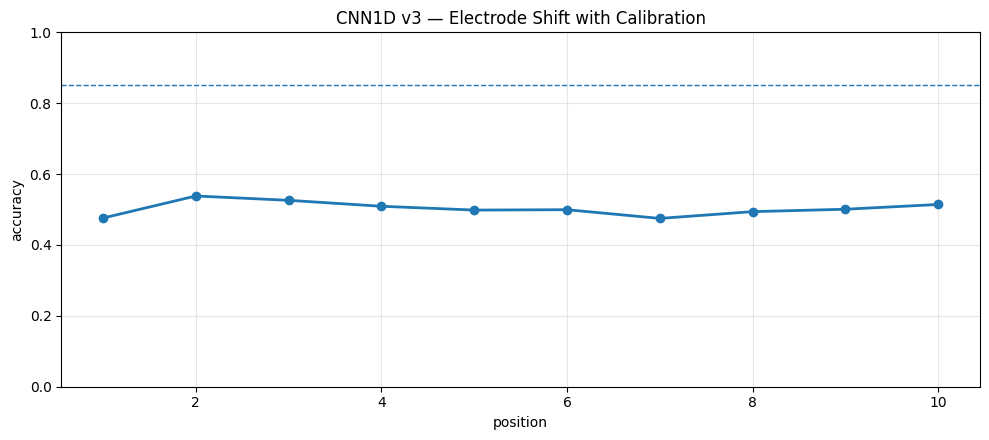

In [14]:
RUN_SHIFT = True

if RUN_SHIFT:
    shift_base_model, shift_mean, shift_std, shift_base_hist = fit_from_df(
        shift_base_df,
        epochs=BASE_EPOCHS,
        lr=LR_BASE,
        augment=True,
        title="shift_base_p0",
    )

    torch.save({"model": shift_base_model.state_dict(), "mean": shift_mean, "std": shift_std}, MODELS_DIR / "cnn1d_v3_shift_base.pt")

    shift_adapted_model, shift_adapt_hist = adapt_model(
        shift_base_model,
        shift_cal_df,
        shift_mean,
        shift_std,
        epochs=ADAPT_EPOCHS,
        lr=LR_ADAPT,
        mode="head_last",
        title="shift_adapt_fullpos",
    )

    torch.save({"model": shift_adapted_model.state_dict(), "mean": shift_mean, "std": shift_std}, MODELS_DIR / "cnn1d_v3_shift_adapted.pt")

    shift_curve = evaluate_by_group(shift_adapted_model, shift_test_df, shift_mean, shift_std, group_col="position")
    display(shift_curve)
    save_report("cnn1d_v3_shift_adapted", shift_curve, shift_adapt_hist)
    plot_curve(shift_curve, "position", title="CNN1D v3 — Electrode Shift with Calibration", save_name="cnn1d_v3_shift_adapted.png")


## Scenario B — Inter-day with target-session calibration

In [15]:
interday_subset = meta[(meta["subject"].isin(SUBJECTS_INTERDAY_LONG)) & (meta["position"] == 0)].copy()
interday_base_df = interday_subset[interday_subset["session"] == 0].copy()
print("base trials", len(interday_base_df), "base windows", int(interday_base_df["n_windows"].sum()))
print("sessions", sorted(interday_subset["session"].unique()))


base trials 126 base windows 13445
sessions [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


Computing normalization:   0%|          | 0/105 [00:00<?, ?it/s]

interday_base_s0 epoch 1/45:   0%|          | 0/45 [00:00<?, ?it/s]

interday_base_s0 | epoch 01 | train_loss=1.7844 | val_acc=0.4993 | val_f1=0.4673


interday_base_s0 epoch 2/45:   0%|          | 0/45 [00:00<?, ?it/s]

interday_base_s0 | epoch 02 | train_loss=1.6025 | val_acc=0.5647 | val_f1=0.5617


...

interday_adapt_s9 epoch 9/18:   0%|          | 0/31 [00:00<?, ?it/s]

interday_adapt_s9 | epoch 09 | train_loss=1.2792 | val_acc=0.5903 | val_f1=0.5937


interday_adapt_s9 epoch 10/18:   0%|          | 0/31 [00:00<?, ?it/s]

interday_adapt_s9 | epoch 10 | train_loss=1.2643 | val_acc=0.6014 | val_f1=0.5993
Early stopping at epoch 10


,session,accuracy,f1_macro,n_windows
0,1,0.617521,0.628388,4680
1,2,0.620682,0.622607,4690
2,3,0.579335,0.580764,4481
3,4,0.709891,0.711923,4681
4,5,0.692549,0.698550,4778
5,6,0.674370,0.676389,4760
6,7,0.685278,0.690842,4782
7,8,0.708032,0.711815,4569
8,9,0.687036,0.691469,4582


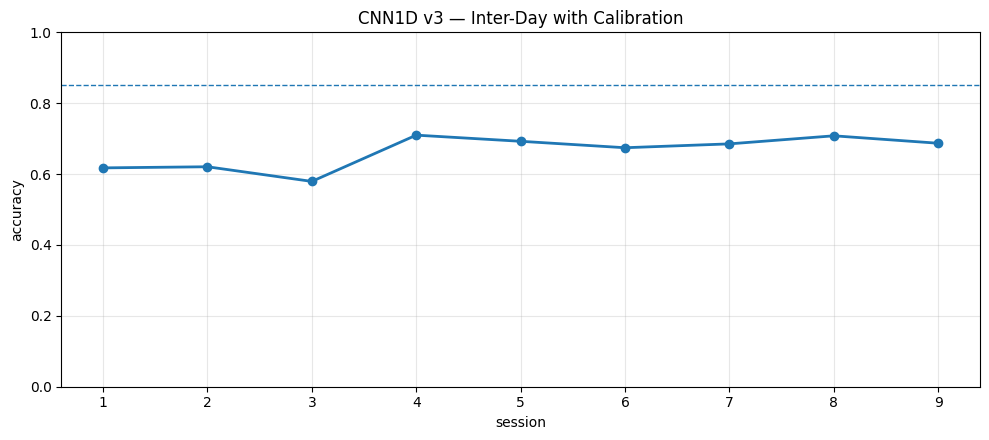

In [16]:
RUN_INTERDAY = True

if RUN_INTERDAY:
    interday_base_model, interday_mean, interday_std, interday_base_hist = fit_from_df(
        interday_base_df,
        epochs=BASE_EPOCHS,
        lr=LR_BASE,
        augment=True,
        title="interday_base_s0",
    )

    torch.save({"model": interday_base_model.state_dict(), "mean": interday_mean, "std": interday_std}, MODELS_DIR / "cnn1d_v3_interday_base.pt")

    interday_rows = []
    interday_histories = []

    for sess in sorted([s for s in interday_subset["session"].unique() if s != 0]):
        cal_df = interday_subset[
            (interday_subset["session"] == sess) &
            (interday_subset["repetition"].isin(INTERDAY_CAL_REPS))
        ].copy()
        test_df = interday_subset[
            (interday_subset["session"] == sess) &
            (interday_subset["repetition"].isin(INTERDAY_TEST_REPS))
        ].copy()

        adapted, hist = adapt_model(
            interday_base_model,
            cal_df,
            interday_mean,
            interday_std,
            epochs=ADAPT_EPOCHS,
            lr=LR_ADAPT,
            mode="head_last",
            title=f"interday_adapt_s{sess}",
        )

        loader = make_loader(test_df, interday_mean, interday_std, shuffle=False, augment=False)
        res = evaluate(adapted, loader)
        interday_rows.append({"session": sess, "accuracy": res["accuracy"], "f1_macro": res["f1_macro"], "n_windows": len(loader.dataset)})
        hist["target_session"] = sess
        interday_histories.append(hist)
        torch.save({"model": adapted.state_dict(), "mean": interday_mean, "std": interday_std}, MODELS_DIR / f"cnn1d_v3_interday_s{sess}.pt")

    interday_curve = pd.DataFrame(interday_rows)
    display(interday_curve)
    all_interday_hist = pd.concat(interday_histories, ignore_index=True) if interday_histories else None
    save_report("cnn1d_v3_interday_adapted", interday_curve, all_interday_hist)
    plot_curve(interday_curve, "session", title="CNN1D v3 — Inter-Day with Calibration", save_name="cnn1d_v3_interday_adapted.png")


## Scenario C — Fatigue robustness

In [17]:
fatigue_subset = meta[meta["subject"].isin(SUBJECTS_FATIGUE)].copy()
fatigue_train_df = fatigue_subset[fatigue_subset["position"].isin([0, 1])].copy()
fatigue_test_df = fatigue_subset[fatigue_subset["position"] >= 2].copy()

print("train trials", len(fatigue_train_df), "test trials", len(fatigue_test_df))
print("train windows", int(fatigue_train_df["n_windows"].sum()), "test windows", int(fatigue_test_df["n_windows"].sum()))


train trials 252 test trials 1132
train windows 33046 test windows 148919


Computing normalization:   0%|          | 0/217 [00:00<?, ?it/s]

fatigue_train epoch 1/35:   0%|          | 0/112 [00:00<?, ?it/s]

fatigue_train | epoch 01 | train_loss=1.5612 | val_acc=0.6078 | val_f1=0.6008


fatigue_train epoch 2/35:   0%|          | 0/112 [00:00<?, ?it/s]

fatigue_train | epoch 02 | train_loss=1.3021 | val_acc=0.6654 | val_f1=0.6750


...

fatigue_train epoch 22/35:   0%|          | 0/112 [00:00<?, ?it/s]

fatigue_train | epoch 22 | train_loss=0.7729 | val_acc=0.8127 | val_f1=0.8127


fatigue_train epoch 23/35:   0%|          | 0/112 [00:00<?, ?it/s]

fatigue_train | epoch 23 | train_loss=0.7602 | val_acc=0.8282 | val_f1=0.8300
Early stopping at epoch 23


,position,accuracy,f1_macro,n_windows
0,2,0.845848,0.847805,16607
1,3,0.834148,0.835470,16563
2,4,0.841135,0.841182,16429
3,5,0.841236,0.840895,16641
4,6,0.850589,0.851561,16565
5,7,0.857590,0.859083,16628
6,8,0.804617,0.804786,16547
7,9,0.818994,0.819165,16563
8,10,0.828530,0.827330,16376


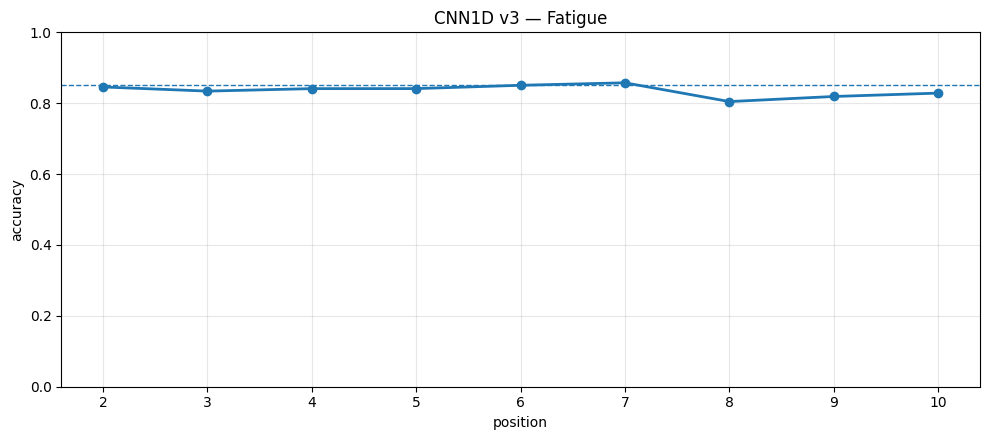

In [18]:
RUN_FATIGUE = True

if RUN_FATIGUE:
    fatigue_model, fatigue_mean, fatigue_std, fatigue_hist = fit_from_df(
        fatigue_train_df,
        epochs=FATIGUE_EPOCHS,
        lr=LR_BASE,
        augment=True,
        title="fatigue_train",
    )

    torch.save({"model": fatigue_model.state_dict(), "mean": fatigue_mean, "std": fatigue_std}, MODELS_DIR / "cnn1d_v3_fatigue.pt")

    fatigue_curve = evaluate_by_group(fatigue_model, fatigue_test_df, fatigue_mean, fatigue_std, group_col="position")
    display(fatigue_curve)
    save_report("cnn1d_v3_fatigue", fatigue_curve, fatigue_hist)
    plot_curve(fatigue_curve, "position", title="CNN1D v3 — Fatigue", save_name="cnn1d_v3_fatigue.png")


## Optional — pure no-calibration baselines

Cell ini untuk pembanding. Jangan jadikan hasil ini target utama jika tujuan penelitian adalah semua skenario >85%, karena electrode shift dan inter-day memang membutuhkan adaptation/calibration.


In [19]:
RUN_NO_CAL_BASELINES = False

if RUN_NO_CAL_BASELINES:
    if 'shift_base_model' in globals():
        no_cal_shift = evaluate_by_group(shift_base_model, shift_test_df, shift_mean, shift_std, group_col="position")
        display(no_cal_shift)
        save_report("cnn1d_v3_shift_no_cal", no_cal_shift)
        plot_curve(no_cal_shift, "position", title="CNN1D v3 — Shift without Calibration", save_name="cnn1d_v3_shift_no_cal.png")

    if 'interday_base_model' in globals():
        rows = []
        for sess in sorted([s for s in interday_subset["session"].unique() if s != 0]):
            test_df = interday_subset[(interday_subset["session"] == sess)].copy()
            loader = make_loader(test_df, interday_mean, interday_std, shuffle=False, augment=False)
            res = evaluate(interday_base_model, loader)
            rows.append({"session": sess, "accuracy": res["accuracy"], "f1_macro": res["f1_macro"], "n_windows": len(loader.dataset)})
        no_cal_interday = pd.DataFrame(rows)
        display(no_cal_interday)
        save_report("cnn1d_v3_interday_no_cal", no_cal_interday)
        plot_curve(no_cal_interday, "session", title="CNN1D v3 — Inter-Day without Calibration", save_name="cnn1d_v3_interday_no_cal.png")


## Final summary

In [20]:
summary_rows = []

if 'shift_curve' in globals():
    summary_rows.append({
        "scenario": "electrode_shift_calibrated",
        "mean_accuracy": shift_curve["accuracy"].mean(),
        "min_accuracy": shift_curve["accuracy"].min(),
        "mean_f1_macro": shift_curve["f1_macro"].mean(),
    })

if 'interday_curve' in globals():
    summary_rows.append({
        "scenario": "interday_calibrated",
        "mean_accuracy": interday_curve["accuracy"].mean(),
        "min_accuracy": interday_curve["accuracy"].min(),
        "mean_f1_macro": interday_curve["f1_macro"].mean(),
    })

if 'fatigue_curve' in globals():
    summary_rows.append({
        "scenario": "fatigue",
        "mean_accuracy": fatigue_curve["accuracy"].mean(),
        "min_accuracy": fatigue_curve["accuracy"].min(),
        "mean_f1_macro": fatigue_curve["f1_macro"].mean(),
    })

summary = pd.DataFrame(summary_rows)
display(summary)
summary.to_csv(RESULTS_DIR / "logs" / "cnn1d_v3_summary.csv", index=False)


,scenario,mean_accuracy,min_accuracy,mean_f1_macro
0,electrode_shift_calibrated,0.503139,0.474924,0.501792
1,interday_calibrated,0.663855,0.579335,0.668083
2,fatigue,0.835854,0.804617,0.836364


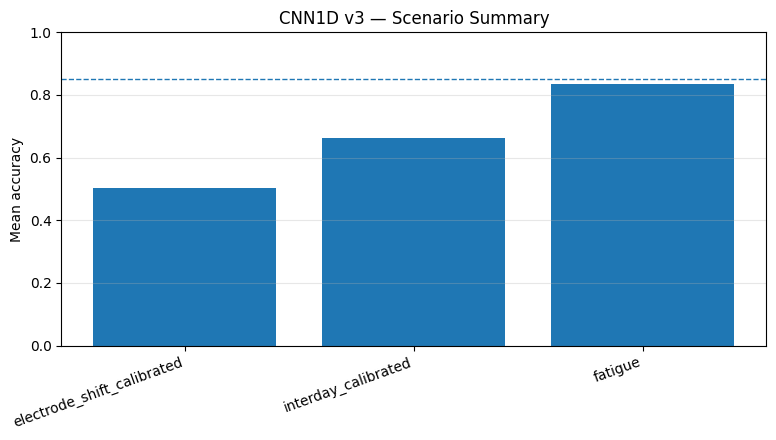

In [21]:
if 'summary' in globals() and len(summary):
    plt.figure(figsize=(8, 4.5))
    plt.bar(summary["scenario"], summary["mean_accuracy"])
    plt.axhline(0.85, linestyle="--", linewidth=1)
    plt.ylim(0, 1.0)
    plt.ylabel("Mean accuracy")
    plt.title("CNN1D v3 — Scenario Summary")
    plt.xticks(rotation=20, ha="right")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "cnn1d_v3_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
